In [1]:
import geokit as gk
from geokit.core.get_test_data import get_test_data
import matplotlib.pyplot as plt

#### This example shows how to warp an external raster (like GHI data) to match a region's alignment and then extract statistics using the mask.

Mean GHI in Region: 2.9311041831970215


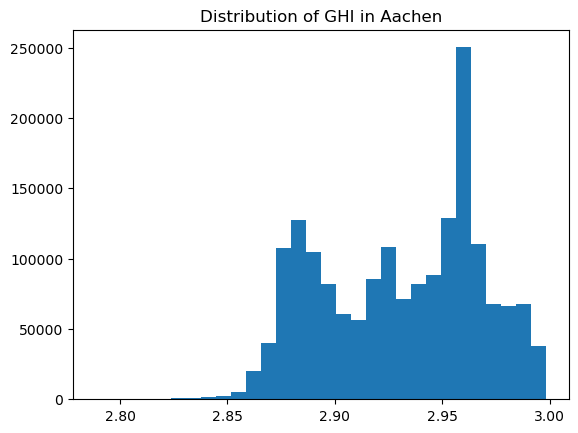

In [3]:
# Load mask
aachen_rm = gk.RegionMask.load(get_test_data("aachenShapefile.shp"), srs=3035, pixelRes=20)
raster_path = get_test_data("gsa-ghi-like.tif")

# 1. Warp raster to the RegionMask alignment
# Setting returnMatrix=True (default) gives us a numpy array
ghi_data = aachen_rm.warp(raster_path)

# 2. Extract values specifically within the mask boundaries
masked_values = ghi_data[aachen_rm.mask]

print(f"Mean GHI in Region: {masked_values.mean()}")

# 3. Visualize
plt.hist(masked_values, bins=30)
plt.title("Distribution of GHI in Aachen")
plt.show()